In [1]:
import pandas as pd
import os
import requests
import json

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [3]:
from preprocessing_utils import preprocess_NVD_data

In [4]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

In [5]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-01.csv.gz'), compression='gzip', header=1)
epss_current


,cve,epss,percentile
0,CVE-1999-0001,0.01141,0.77780
1,CVE-1999-0002,0.10742,0.93087
2,CVE-1999-0003,0.90362,0.99589
3,CVE-1999-0004,0.03215,0.86596
4,CVE-1999-0005,0.25334,0.96035
...,...,...,...
296328,CVE-2025-9994,0.00060,0.19138
296329,CVE-2025-9996,0.00179,0.40027
296330,CVE-2025-9997,0.00182,0.40386
296331,CVE-2025-9998,0.00023,0.04753


# NVD data

In [6]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z' # Do NOT change these dates
date_end_NVD   = '2025-10-01T00:00:00.000Z' # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1 

all_cves = []

while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()
    total_results = data.get("totalResults", 0)

    all_cves.extend(data.get("vulnerabilities", []))

    start_index += results_per_page
    print(start_index)

1000
2000
3000
4000
5000


In [7]:
# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus']!='Reserved') & (df['cve.vulnStatus']!='Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

In [8]:
# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)
    
# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_09.csv"))

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [9]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2026-06-17 10:09:40.847000,2026-06-17 10:09:40.990000
cve.vulnStatus,Analyzed,Analyzed
cve.affected,"[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [..."
cve.metrics.ssvcV203,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN


- show a bar plot with the daily volume of published CVEs

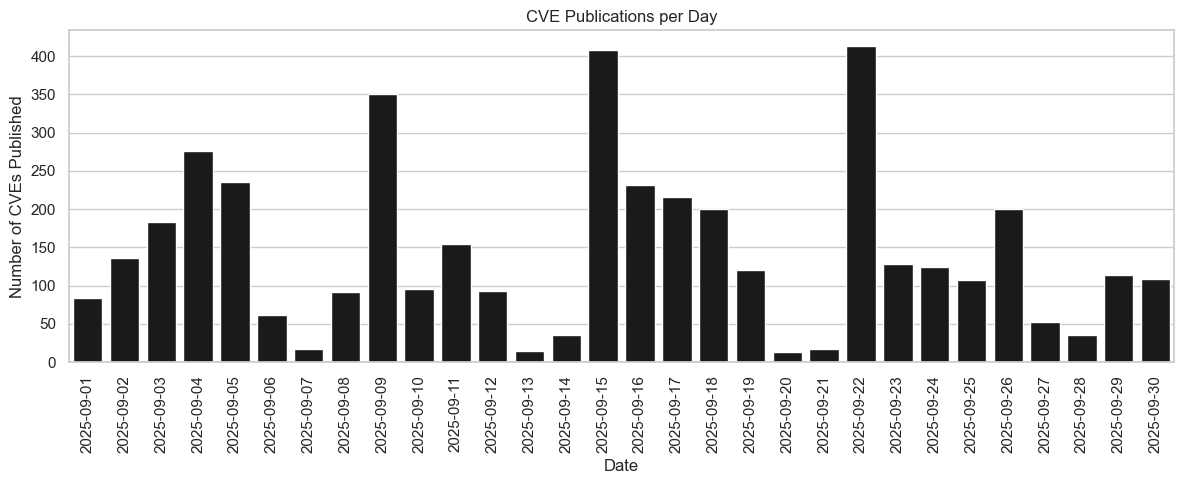

In [10]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k" )
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

- print the description of the last ten published vulnerabilities

In [11]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-'*100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

# <font color='blue'><b><i>TODO</i></b>: produce plots or tables to address the folowing points</font>
- what is the percentage of CVEs which received a CVSS score?
- report descriptive statistics of CVSS the CVSS base score and/or show its distribution
- report descriptive statistics of EPSS and/or show its distribution
- produce a scatter plot showing CVSS vs EPSS
- <b>be creative</b>!
    - How many vulnerabilities are published on CISA KEV? 
    - What are the the 20 most frequent vendors? (vendor name can be extracted from the `vulnerable_cpes` field).
    - What are the 20 most frequent CWEs?
    - Anaything else you see fit!

<font color='blue'>Use text cells to discuss the outcome after each point</font>

## Percentage of CVEs which recived a CVSS score:

In [12]:
total_cves = len(df)
cves_with_cvss = df['cvss_baseScore'].notna().sum()
percentage_cvss = (cves_with_cvss / total_cves) * 100

print(f"Total CVE : {total_cves}")
print(f"CVEs that recived a CVSS score: {cves_with_cvss}")
print(f"Percentage of CVEs which recived a CVSS score: {percentage_cvss:.2f}%")

Total CVE : 4321
CVEs that recived a CVSS score: 4161
Percentage of CVEs which recived a CVSS score: 96.30%


## Statistics of CVSS, the CVSS base score and/or show its distribution

In [13]:

print(df['cvss_baseScore'].describe())

count    4161.000000
mean        6.771305
std         1.715025
min         2.200000
25%         5.500000
50%         6.500000
75%         7.800000
max        10.000000
Name: cvss_baseScore, dtype: float64


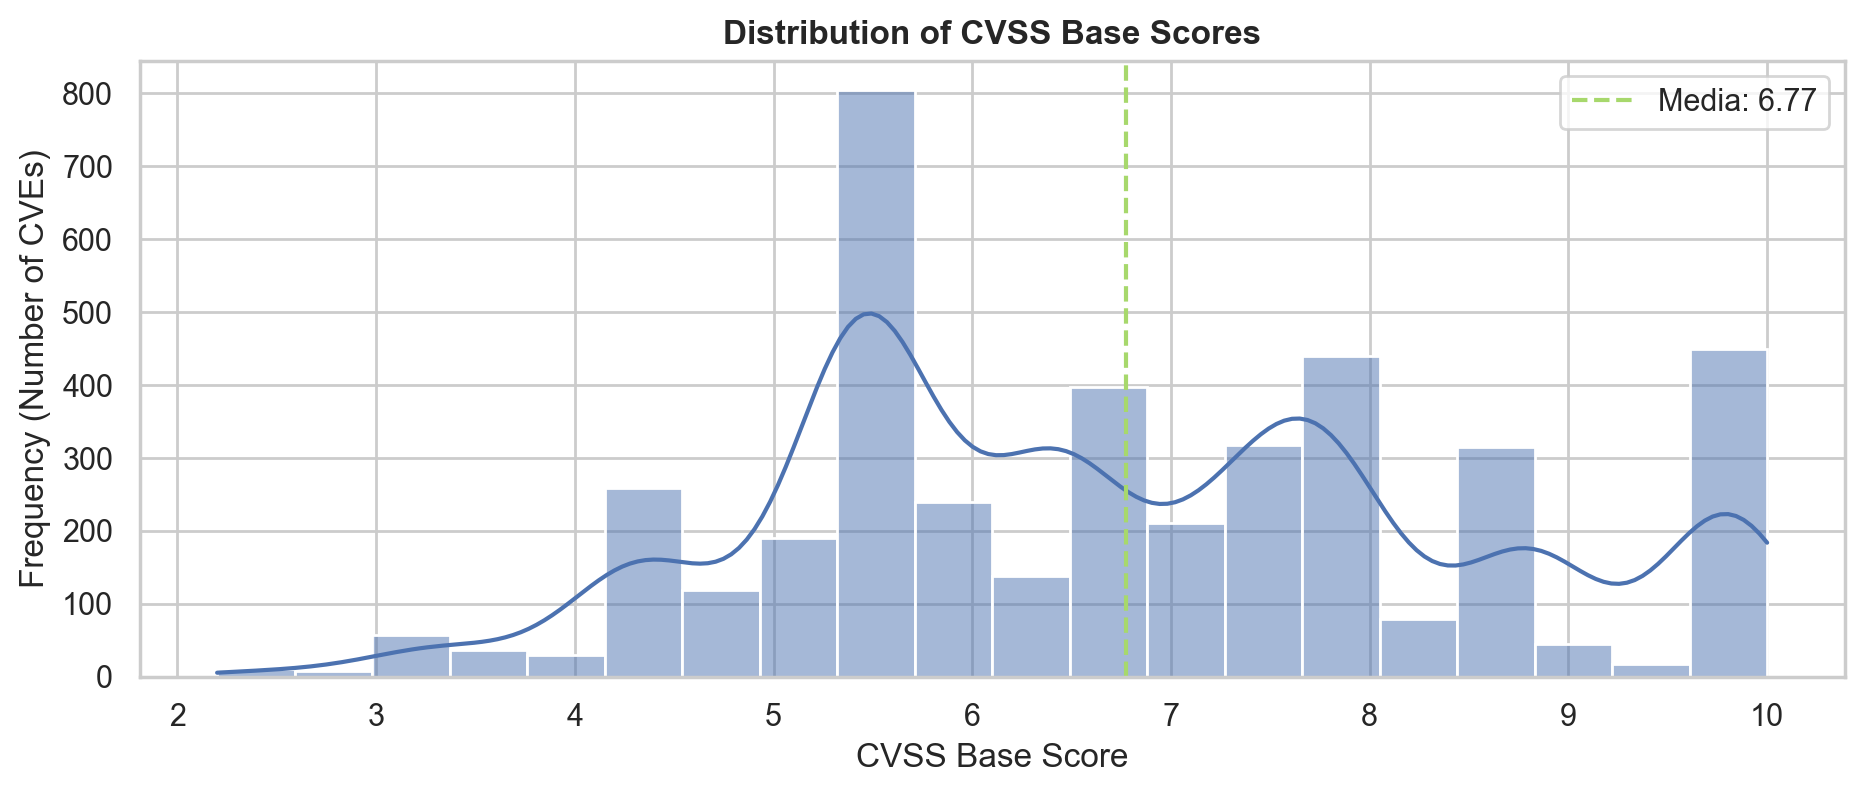

In [14]:
# Distribution of CVSS Base Scores
plt.figure(figsize=(11,4), dpi=200)

sns.histplot(df['cvss_baseScore'], bins=20, kde=True)

plt.axvline(df['cvss_baseScore'].mean(), color='#A7D86C', linestyle='--', linewidth=1.5, label=f"Media: {df['cvss_baseScore'].mean():.2f}")

plt.title('Distribution of CVSS Base Scores', fontweight='bold')
plt.xlabel('CVSS Base Score')
plt.ylabel('Frequency (Number of CVEs)')

plt.legend()
plt.show()

## Statistics of EPSS and/or show its distribution

In [15]:
print(df['epss'].describe())

count    4320.000000
mean        0.001477
std         0.017289
min         0.000020
25%         0.000240
50%         0.000320
75%         0.000470
max         0.810640
Name: epss, dtype: float64


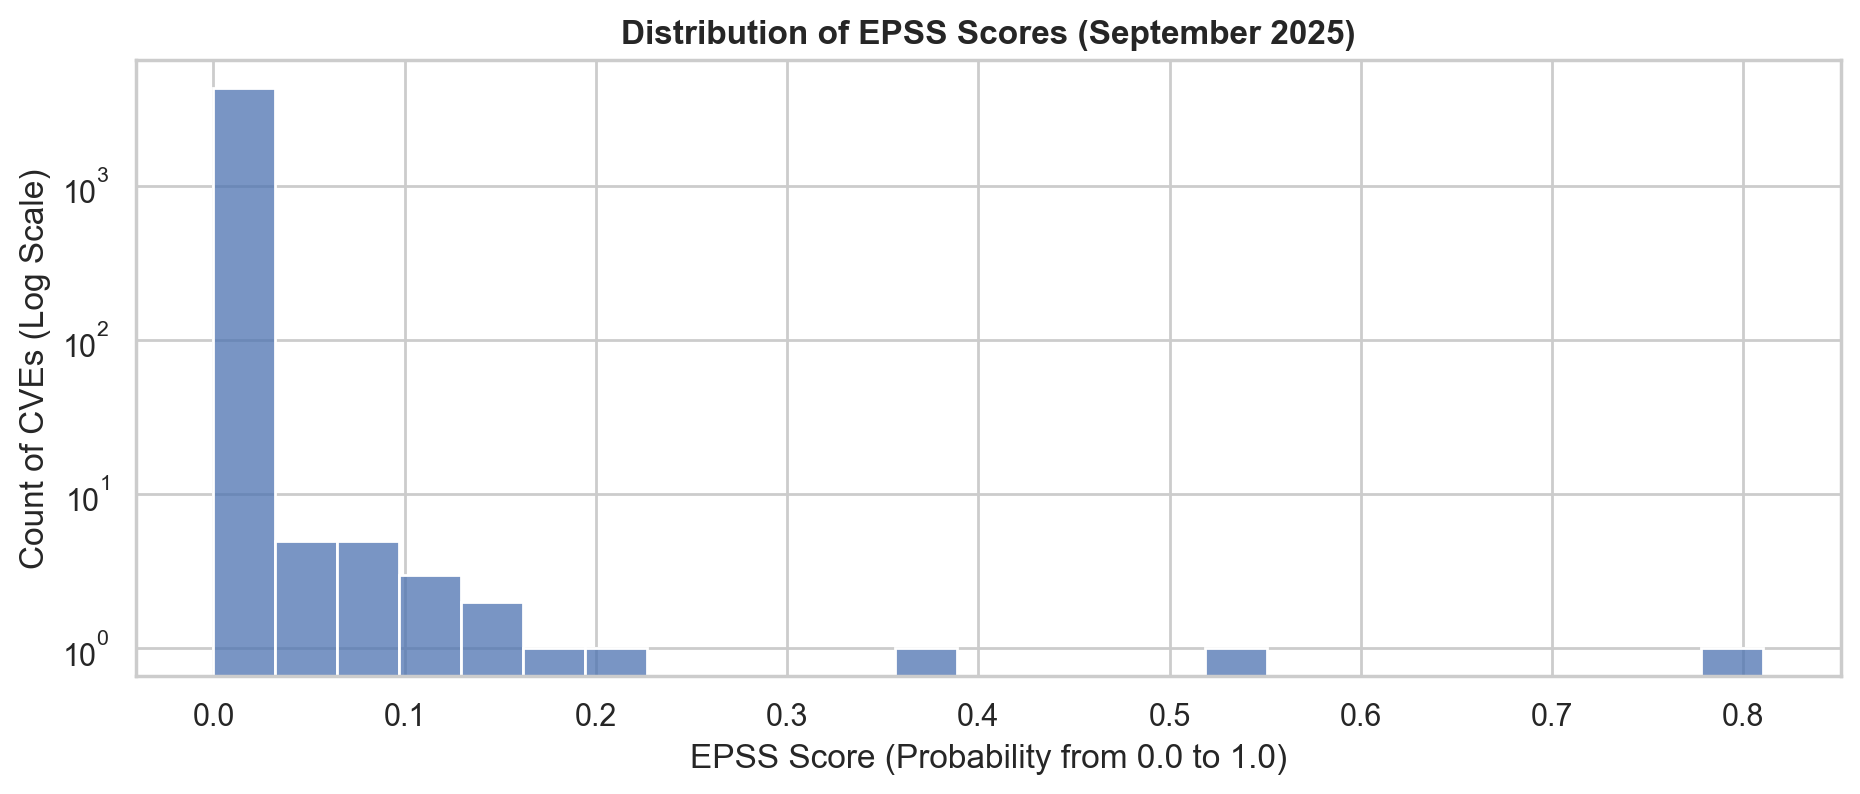

In [16]:
# Distribution of EPSS Scores (September 2025)

plt.figure(figsize=(11, 4), dpi=200)

sns.histplot(df['epss'], bins=25)

plt.yscale('log')

plt.title('Distribution of EPSS Scores (September 2025)', fontweight='bold')
plt.xlabel('EPSS Score (Probability from 0.0 to 1.0)')
plt.ylabel('Count of CVEs (Log Scale)')

plt.show()

## Scatter plot showing CVSS vs EPSS

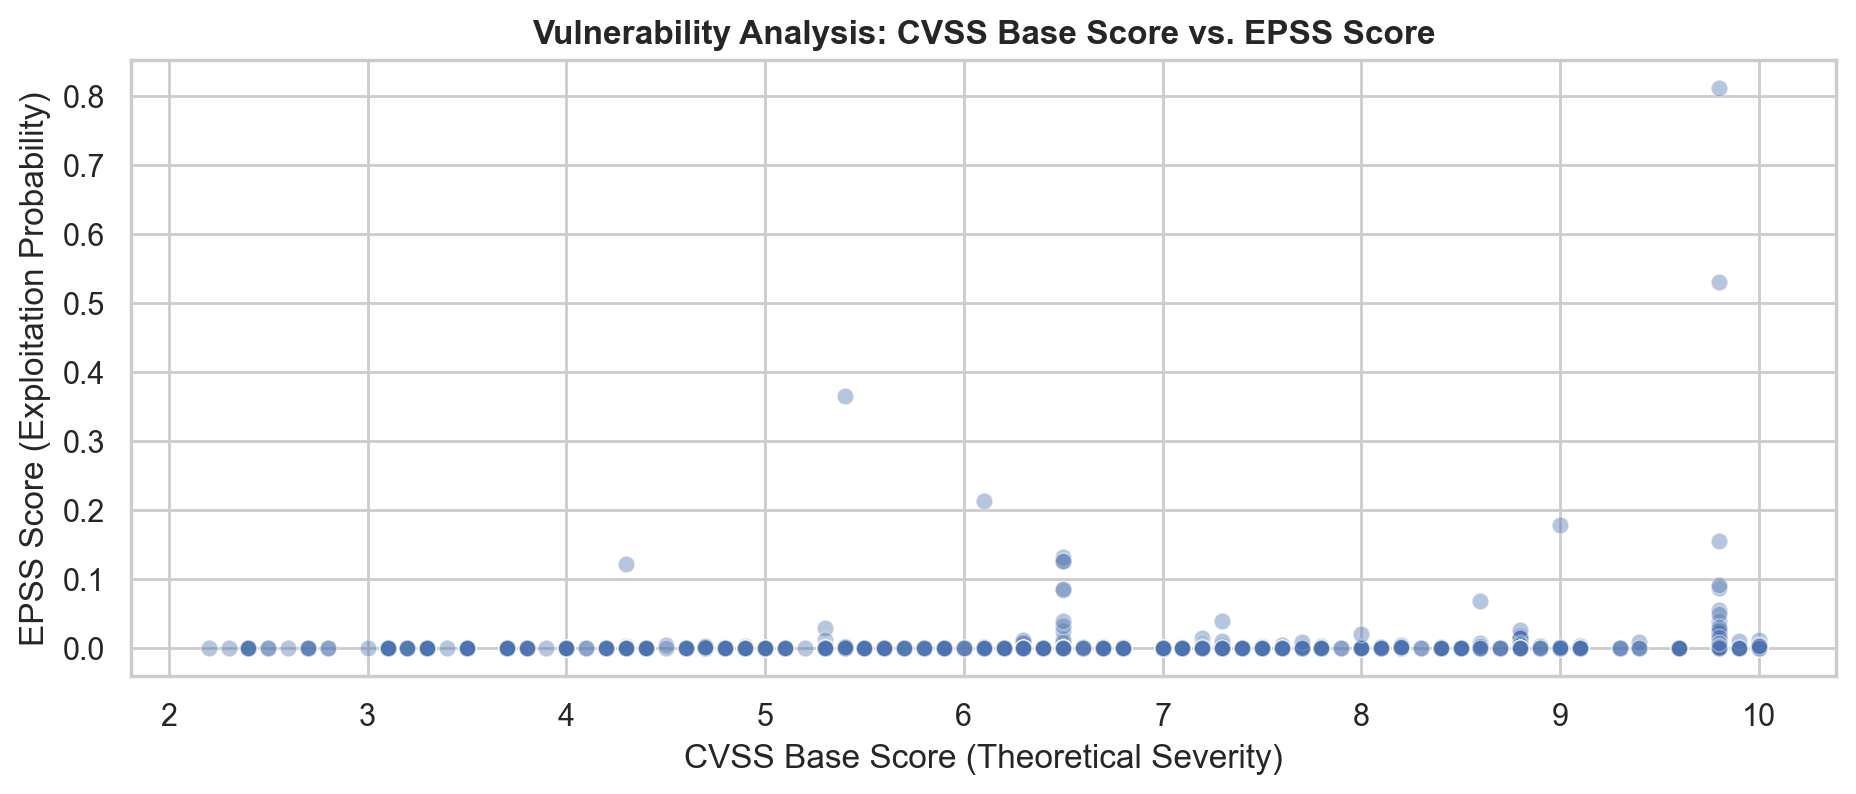

In [17]:
# Vulnerability Analysis: CVSS Base Score vs. EPSS Score

plt.figure(figsize=(11, 4), dpi=200)

sns.scatterplot(
    data=df,
    x='cvss_baseScore',
    y='epss',
    alpha=0.4, 
)

plt.title('Vulnerability Analysis: CVSS Base Score vs. EPSS Score', fontweight='bold')
plt.xlabel('CVSS Base Score (Theoretical Severity)')
plt.ylabel('EPSS Score (Exploitation Probability)')

plt.show()

## Most 20 frequent vendors

In [18]:

import re #Regular Expression

def extract_vendors(cpe_entry):
    # Estrae il nome del vendor presente tra cpe:2.3:<part>: e :<product>
    vendors = re.findall(r'cpe:2\.3:[aoh]:([^:]+):', str(cpe_entry))
    
    return list(set(vendors))

df['vendors'] = df['vulnerable_cpes'].apply(extract_vendors)
vendors_series = df['vendors'].explode()

top_20_vendors = vendors_series.value_counts().head(20)

print(top_20_vendors)

vendors
linux              737
google             178
debian             139
microsoft           94
apple               83
campcodes           73
liferay             49
phpgurukul          47
tenda               45
ibm                 44
vasion              41
samsung             39
apprain             32
fabian              31
ashlar              30
angeljudesuarez     27
portabilis          26
dlink               25
linuxfoundation     24
adobe               24
Name: count, dtype: int64


## Vulnerabilities published on CISA KEV

In [19]:
print("Number of vulnerabilities published on CISA KEV: ", df["cve.cisaRequiredAction"].notna().sum()) 

Number of vulnerabilities published on CISA KEV:  15


## 20 most frequent CWEs

In [20]:
cwes_series = df['cwe_list'].explode()
top_20_cwes = cwes_series.value_counts().head(20)

print(top_20_cwes)

cwe_list
CWE-79     718
CWE-89     435
CWE-74     294
CWE-476    247
CWE-401    216
CWE-862    203
CWE-416    174
CWE-352    162
CWE-94     134
CWE-125    126
CWE-284    121
CWE-787    113
CWE-77     101
CWE-78      90
CWE-434     89
CWE-918     76
CWE-22      73
CWE-20      67
CWE-200     66
CWE-362     65
Name: count, dtype: int64


# CVE selection


### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time


In [21]:

low_epss = df[df["epss"] < 0.01]

## Filter criteria

- Restricts candidates to High and Critical vulnerabilities

- Requires Network accessibility, No Privileges (unauthenticated), and No User Interaction. This removes all operational barriers, allowing frictionless, automated remote attacks without social engineering or leaked credentials.

- Ensures severe functional consequences, specifically arbitrary state modification/code execution (Integrity) and total service disruption (Availability).

In [22]:

candidates_cvss = low_epss[ 
    (low_epss["cvss_baseScore"] >= 8) #Ensures we only keep high or critical severity vulnerabilities
    &(low_epss["cvss_userInteraction"] == "NONE") #Confirms zero victim interaction is required for exploitation
    &(low_epss["cvss_attackVector"] == "NETWORK") #Ensures the vulnerability is remotely exploitable over the network
    &(low_epss["cvss_privilegesRequired"] == "NONE") #Ensures the attack requires no privileges (unauthenticated)
    &(low_epss["cvss_integrityImpact"] == "HIGH") #Requires maximum impact on system data/logic integrity
    &(low_epss["cvss_availabilityImpact"] == "HIGH") #Requires maximum impact on service or system availability
].copy()


Candidates were ranked by external link volume and filtered for count > 6 to isolate vulnerabilities with active community disclosures

In [23]:

candidates_cvss["count"] = candidates_cvss["cve.references"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

# Rank candidates to prioritize active disclosures
candidates_cvss = candidates_cvss.sort_values(by="count", ascending=False)

# Isolate high-traction candidates
candidates_cvss = candidates_cvss[candidates_cvss["count"] > 6].copy()

print(candidates_cvss[["cve", "count", "cvss_baseScore"]].head(10))

                 cve  count  cvss_baseScore
2228  CVE-2025-43359     15             9.8
2217  CVE-2025-43343     15             9.8
2216  CVE-2025-43342     12             9.8
2160  CVE-2025-31255     11             9.8
2220  CVE-2025-43347     10             9.8
3032  CVE-2025-10769     10             9.8
2714  CVE-2025-10666      9             9.8
76     CVE-2025-9794      9             9.8
3044  CVE-2025-10779      9             9.8
160    CVE-2025-9829      8             9.8


## Submission

In [28]:
nickname = 'echo' # TODO: put your nickname here


# TODO: put your selected IDs here
selected = ['CVE-2025-43359',
            'CVE-2025-43343',
            'CVE-2025-43342',
            'CVE-2025-31255',
            'CVE-2025-43347',
            'CVE-2025-10769',
            'CVE-2025-10666',
            'CVE-2025-9794',
            'CVE-2025-10779',
            'CVE-2025-9829',
           ]            

df[df['cve.id'].isin(selected)].to_csv(os.path.join(data_path, f'{nickname}.csv'))            

## Track EPSS 

In [29]:
from datetime import date, timedelta


epss_history = []


start_date = date(2025, 10, 1)
end_date = date.today()

current_date = start_date
while current_date <= end_date:
    date_str = current_date.strftime("%Y-%m-%d")
    
    cves_str = ",".join(selected)
    url = f"https://api.first.org/data/v1/epss?cve={cves_str}&date={date_str}"
    
    data = requests.get(url).json().get("data", [])
    
    for entry in data:
        epss_history.append({
            "cve": entry.get("cve"),
            "date": entry.get("date"),
            "epss": float(entry.get("epss", 0)),
            "percentile": float(entry.get("percentile", 0))
        })
        
    # Slampled the EPSS data every 4 days to reduce data volume.
    current_date += timedelta(days=4)

print(f"Totale record scaricati: {len(epss_history)}")


Totale record scaricati: 850


In [30]:
df_history = pd.DataFrame(epss_history)
df_history["date"] = pd.to_datetime(df_history["date"])

df_history = df_history.sort_values(by=["cve", "date"]).reset_index(drop=True)

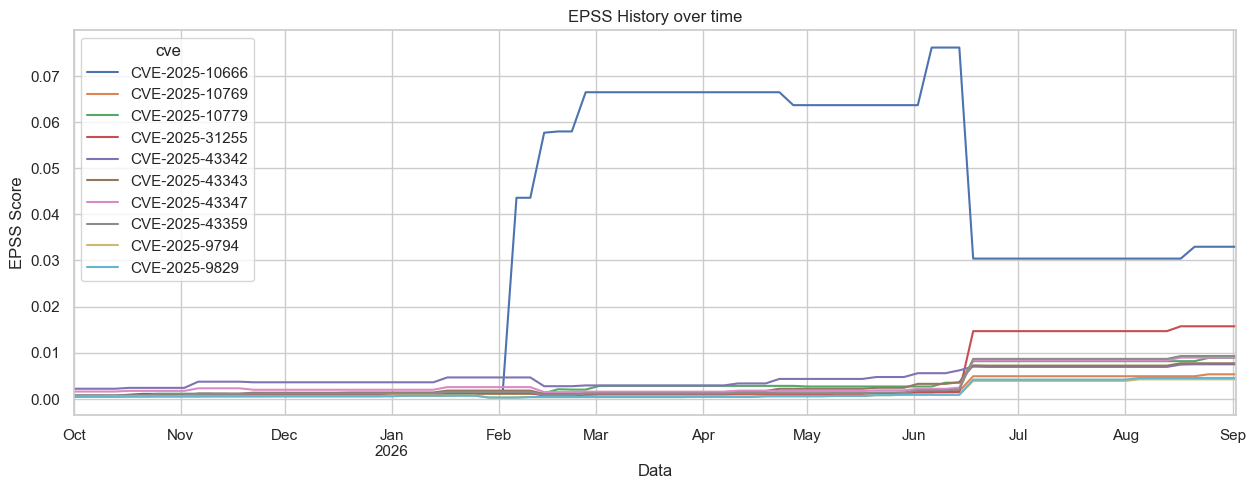

In [31]:
import matplotlib.pyplot as plt

df_history.pivot(index="date", columns="cve", values="epss").plot(figsize=(15, 5))

plt.xlabel("Data")
plt.title("EPSS History over time")
plt.ylabel("EPSS Score")



plt.show()

The historical EPSS tracking reveals a notable anomaly for CVE-2025-10666, which experienced a sharp escalation, peaking at an EPSS value of approximately 0.08 (an 8% predicted probability of exploitation within the next 30 days), before abruptly collapsing.

## EPSS CVE-2025-10666 Trajectory Analysis (blue)

***Title***

- D-Link DIR-825 apply.cgi sub_4106d4 buffer overflow

***Description:*** 

- A security flaw has been discovered in D-Link DIR-825 up to 2.10. Affected by this vulnerability is the function sub_4106d4 of the file apply.cgi. The manipulation of the argument countdown_time results in buffer overflow. The attack can be executed remotely. The exploit has been released to the public and may be exploited. This vulnerability only affects products that are no longer supported by the maintainer.

***NVD Last Update:***
- Jun 17, 2026 

>This date corresponds with the collapse observed in the graph.
